# Strategy Landscape Visualizer (close-to-close)

This notebook visualizes whether any strategy (feature set × model × horizon) has an "always-win" landscape, or whether performance is regime-dependent.

It uses the latest pipeline outputs in `outputs/` and focuses on **execution_mode = close_to_close** (as requested).

**Key visualizations**
1) Heatmaps: Sharpe / annualized return / max drawdown across (feature set × model × horizon)
2) Equity curves: SPY + multiple strategies
3) Rolling-window performance (e.g., 63D rolling Sharpe)
4) "Winner map": which strategy is best over time (rolling Sharpe)


In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

ROOT = Path(r'C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2')
OUT = ROOT / 'outputs'
TAG = '02'
MODE = 'live'
EXEC_MODE = 'open_to_open'  # focus mode

metrics_path = OUT / 'metrics' / f'{TAG}_{MODE}_metrics.csv'
bt_path = OUT / 'metrics' / f'{TAG}_{MODE}_backtest_summary.csv'
rel_path = OUT / 'metrics' / f'{TAG}_{MODE}_relative_summary.csv'
curves_dir = OUT / 'curves'

assert metrics_path.exists(), metrics_path
assert bt_path.exists(), bt_path
assert rel_path.exists(), rel_path
print('OK:', metrics_path.name, bt_path.name, rel_path.name)

OK: 02_live_metrics.csv 02_live_backtest_summary.csv 02_live_relative_summary.csv


## 1) Load tables and build one merged view

In [5]:
metrics = pd.read_csv(metrics_path)
bt = pd.read_csv(bt_path)
rel = pd.read_csv(rel_path)

KEY = ['feature_set','model','horizon_days']
df = bt.merge(rel, on=KEY+['execution_mode'], how='left')
df = df.merge(metrics, on=KEY, how='left', suffixes=('','_ml'))

df = df[df['execution_mode'] == EXEC_MODE].copy()
print('Merged rows (filtered):', len(df))
df[['feature_set','model','horizon_days','execution_mode','sharpe','annualized_return','max_drawdown','alpha_ann','information_ratio','balanced_accuracy','rank_ic']].sort_values(['horizon_days','sharpe'], ascending=[True,False]).head(10)

Merged rows (filtered): 20


,feature_set,model,horizon_days,execution_mode,sharpe,annualized_return,max_drawdown,alpha_ann,information_ratio,balanced_accuracy,rank_ic
12,F4_plus_cross_sectional,logistic_regression,1,open_to_open,0.849264,0.225976,-0.236580,0.057136,0.282541,0.501135,0.009005
16,F5_full_finance_no_fundamental,logistic_regression,1,open_to_open,0.218705,0.021825,-0.248350,-0.147016,-0.399184,0.502729,0.007104
8,F3_plus_risk_liquidity,logistic_regression,1,open_to_open,-0.405466,-0.158663,-0.305030,-0.327503,-1.122552,0.504423,0.007478
14,F4_plus_cross_sectional,random_forest,1,open_to_open,-0.606996,-0.167379,-0.261188,-0.336220,-1.397868,0.507851,0.011681
4,F2_momentum_reversal,logistic_regression,1,open_to_open,-0.819393,-0.253377,-0.376245,-0.422218,-1.610438,0.505502,0.005092
10,F3_plus_risk_liquidity,random_forest,1,open_to_open,-0.916339,-0.260110,-0.369181,-0.428950,-1.645459,0.504832,0.007950
6,F2_momentum_reversal,random_forest,1,open_to_open,-0.991478,-0.266658,-0.382961,-0.435499,-1.719667,0.503749,0.007643
0,F1_momentum,logistic_regression,1,open_to_open,-1.027978,-0.323279,-0.472713,-0.492119,-1.791356,0.505308,0.009852
2,F1_momentum,random_forest,1,open_to_open,-1.150226,-0.291659,-0.414022,-0.460500,-1.850693,0.502586,0.007519
18,F5_full_finance_no_fundamental,random_forest,1,open_to_open,-1.410994,-0.223680,-0.332453,-0.392520,-2.180744,0.501622,-0.001507


## 2) Heatmaps: strategy performance landscape
We make heatmaps of Sharpe and alpha across (feature set × model), separately for each horizon.

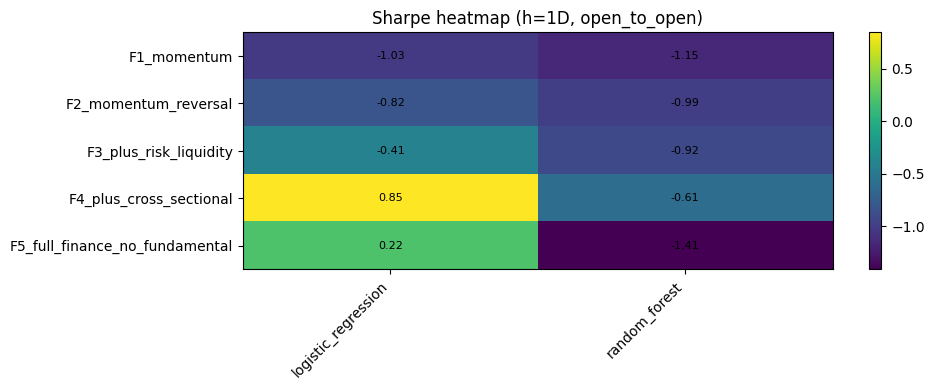

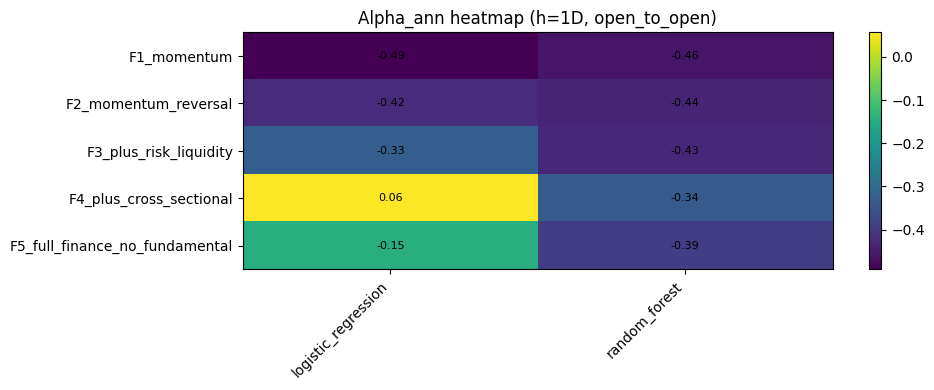

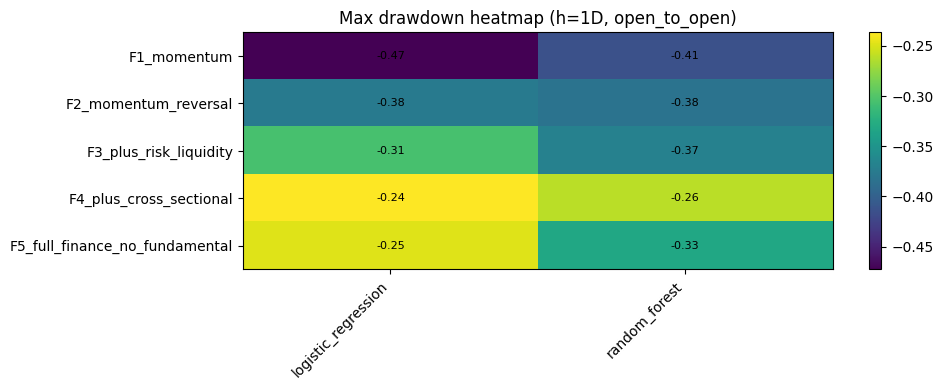

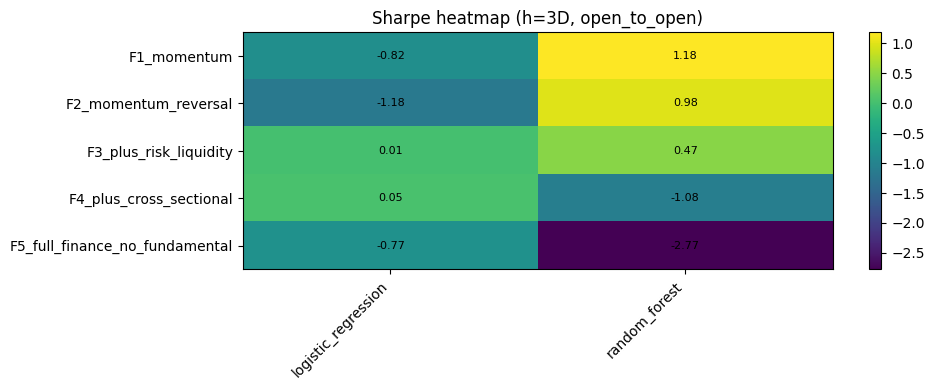

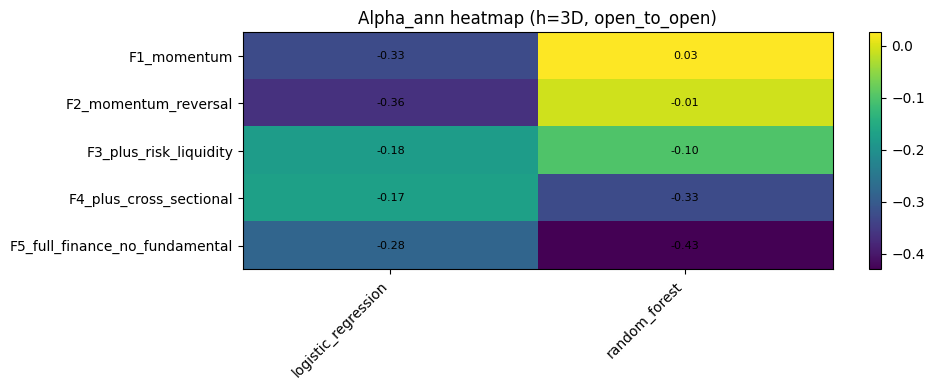

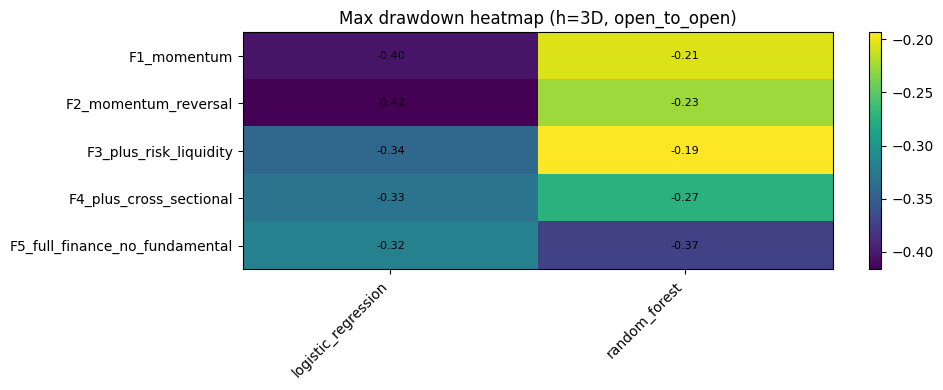

In [6]:
def heatmap(pivot, title):
    if pivot.empty: return
    plt.figure(figsize=(10, 4))
    plt.imshow(pivot.values, aspect='auto')
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
    plt.yticks(range(len(pivot.index)), pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iloc[i, j]
            s = 'NA' if pd.isna(v) else f'{v:.2f}'
            plt.text(j, i, s, ha='center', va='center', fontsize=8)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

for h in sorted(df.horizon_days.unique()):
    sub = df[df.horizon_days == h]
    p = sub.pivot_table(index='feature_set', columns='model', values='sharpe', aggfunc='first')
    heatmap(p, f'Sharpe heatmap (h={h}D, {EXEC_MODE})')
    p2 = sub.pivot_table(index='feature_set', columns='model', values='alpha_ann', aggfunc='first')
    heatmap(p2, f'Alpha_ann heatmap (h={h}D, {EXEC_MODE})')
    p3 = sub.pivot_table(index='feature_set', columns='model', values='max_drawdown', aggfunc='first')
    heatmap(p3, f'Max drawdown heatmap (h={h}D, {EXEC_MODE})')

## 3) Load all curve CSVs for this execution mode
Each strategy has a daily return series saved under `outputs/curves/` from the pipeline.

In [7]:
pattern = f'{TAG}_{MODE}_*_daily.csv'
curve_files = sorted(curves_dir.glob(pattern))
print('Total curve files:', len(curve_files))

# Strategy curves for the chosen execution mode
strat_files = [p for p in curve_files if p.name.endswith(f'{EXEC_MODE}_daily.csv')]
print('Strategy curves (this exec mode):', len(strat_files))
strat_files[:5]

Total curve files: 44
Strategy curves (this exec mode): 20


[WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs/curves/02_live_F1_momentum_logistic_regression_1d_open_to_open_daily.csv'),
 WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs/curves/02_live_F1_momentum_logistic_regression_3d_open_to_open_daily.csv'),
 WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs/curves/02_live_F1_momentum_random_forest_1d_open_to_open_daily.csv'),
 WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs/curves/02_live_F1_momentum_random_forest_3d_open_to_open_daily.csv'),
 WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs/curves/02_live_F2_momentum_reversal_logistic_regression_1d_open_to_open_daily.csv')]

In [8]:
def load_curve(path: Path):
    d = pd.read_csv(path)
    d['date'] = pd.to_datetime(d['date'])
    d = d.sort_values('date')
    if 'equity' not in d.columns and 'net_ret' in d.columns:
        d['equity'] = (1 + d['net_ret']).cumprod()
    return d

curves = {}
for p in strat_files:
    name = p.stem.replace(f'{TAG}_{MODE}_','')
    curves[name] = load_curve(p)

print('Loaded curves:', len(curves))
list(curves.keys())[:10]

Loaded curves: 20


['F1_momentum_logistic_regression_1d_open_to_open_daily',
 'F1_momentum_logistic_regression_3d_open_to_open_daily',
 'F1_momentum_random_forest_1d_open_to_open_daily',
 'F1_momentum_random_forest_3d_open_to_open_daily',
 'F2_momentum_reversal_logistic_regression_1d_open_to_open_daily',
 'F2_momentum_reversal_logistic_regression_3d_open_to_open_daily',
 'F2_momentum_reversal_random_forest_1d_open_to_open_daily',
 'F2_momentum_reversal_random_forest_3d_open_to_open_daily',
 'F3_plus_risk_liquidity_logistic_regression_1d_open_to_open_daily',
 'F3_plus_risk_liquidity_logistic_regression_3d_open_to_open_daily']

## 4) Equity curves: overview
Plot SPY and a selected subset (e.g., top Sharpe per horizon).

In [9]:
# Load SPY daily curve for each horizon (these are daily buy&hold returns and stored by pipeline)
spy_curves = {}
for h in sorted(df.horizon_days.unique()):
    p = curves_dir / f'{TAG}_{MODE}_SPY_{h}d_daily.csv'
    if p.exists():
        spy_curves[h] = load_curve(p)

spy_curves.keys()

dict_keys([np.int64(1), np.int64(3)])

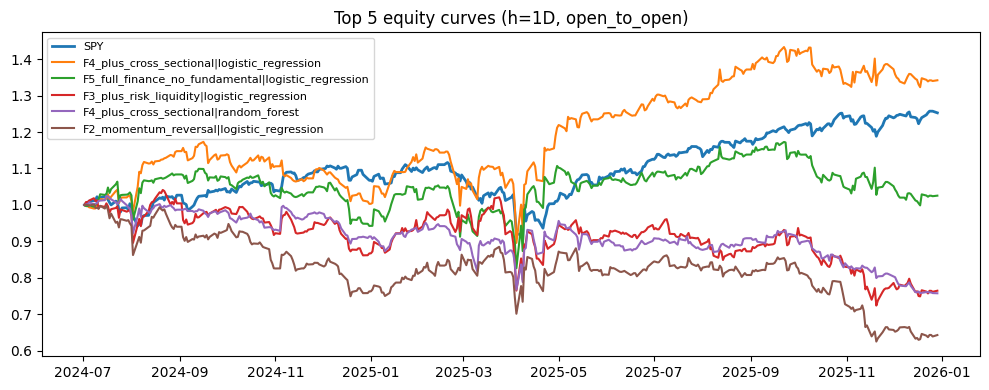

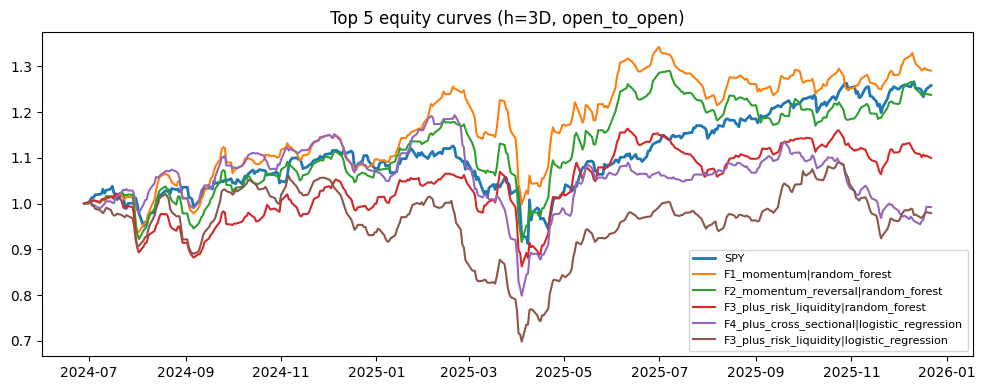

In [15]:
# Pick top N by Sharpe within each horizon from df (table)
TOP_N = 5

for h in sorted(df.horizon_days.unique()):
    sub = df[df.horizon_days == h].sort_values('sharpe', ascending=False).head(TOP_N)

    # Gather selected strategy curves first
    selected_curves = []
    for _, r in sub.iterrows():
        fs, m = r['feature_set'], r['model']
        key = f'{fs}_{m}_{int(h)}d_{EXEC_MODE}_daily'
        if key in curves and not curves[key].empty:
            c = curves[key][['date', 'equity']].copy()
            c['date'] = pd.to_datetime(c['date'])
            c = c.sort_values('date').drop_duplicates('date')
            selected_curves.append((f'{fs}|{m}', c))

    if not selected_curves:
        continue

    # Use common overlapping window across selected strategy curves
    starts = [c['date'].min() for _, c in selected_curves]
    ends = [c['date'].max() for _, c in selected_curves]
    common_start = max(starts)
    common_end = min(ends)

    # Fallback: if overlap is empty, use union window
    if common_start > common_end:
        common_start = min(starts)
        common_end = max(ends)

    ref_idx = pd.date_range(common_start, common_end, freq='B')

    plt.figure(figsize=(10, 4))

    # SPY aligned to strategy date window and rebased to the same start point
    if h in spy_curves and not spy_curves[h].empty:
        spy = spy_curves[h][['date', 'equity']].copy()
        spy['date'] = pd.to_datetime(spy['date'])
        spy = spy.sort_values('date').drop_duplicates('date').set_index('date').reindex(ref_idx)
        spy['equity'] = spy['equity'].ffill().bfill()
        spy0 = spy['equity'].iloc[0]
        if pd.notna(spy0) and spy0 != 0:
            spy['equity'] = spy['equity'] / spy0
        plt.plot(ref_idx, spy['equity'].values, label='SPY', linewidth=2)

    # Strategy curves aligned to same date window and rebased to same start point
    for label, c in selected_curves:
        c_aligned = c.set_index('date').reindex(ref_idx)
        c_aligned['equity'] = c_aligned['equity'].ffill().bfill()
        c0 = c_aligned['equity'].iloc[0]
        if pd.notna(c0) and c0 != 0:
            c_aligned['equity'] = c_aligned['equity'] / c0
        plt.plot(ref_idx, c_aligned['equity'].values, label=label)

    plt.title(f'Top {TOP_N} equity curves (h={h}D, {EXEC_MODE})')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 5) Rolling performance and "winner map"
We compute rolling Sharpe for each strategy and see which one is best over time.

In [16]:
def rolling_sharpe(rets: pd.Series, window=63, periods_per_year=252):
    r = pd.Series(rets).astype(float)
    mu = r.rolling(window).mean() * periods_per_year
    vol = r.rolling(window).std(ddof=0) * np.sqrt(periods_per_year)
    return mu / vol

WINDOW = 63  # ~3 months

# Build a wide dataframe of rolling sharpes aligned by date
roll = None
for name, c in curves.items():
    if 'net_ret' not in c.columns or c.empty:
        continue
    s = rolling_sharpe(c.set_index('date')['net_ret'], window=WINDOW).rename(name)
    roll = s.to_frame() if roll is None else roll.join(s, how='outer')

roll = roll.sort_index()
print('Rolling Sharpe panel:', roll.shape)
roll.tail()

Rolling Sharpe panel: (377, 20)


,F1_momentum_logistic_regression_1d_open_to_open_daily,F1_momentum_logistic_regression_3d_open_to_open_daily,F1_momentum_random_forest_1d_open_to_open_daily,F1_momentum_random_forest_3d_open_to_open_daily,F2_momentum_reversal_logistic_regression_1d_open_to_open_daily,F2_momentum_reversal_logistic_regression_3d_open_to_open_daily,F2_momentum_reversal_random_forest_1d_open_to_open_daily,F2_momentum_reversal_random_forest_3d_open_to_open_daily,F3_plus_risk_liquidity_logistic_regression_1d_open_to_open_daily,F3_plus_risk_liquidity_logistic_regression_3d_open_to_open_daily,F3_plus_risk_liquidity_random_forest_1d_open_to_open_daily,F3_plus_risk_liquidity_random_forest_3d_open_to_open_daily,F4_plus_cross_sectional_logistic_regression_1d_open_to_open_daily,F4_plus_cross_sectional_logistic_regression_3d_open_to_open_daily,F4_plus_cross_sectional_random_forest_1d_open_to_open_daily,F4_plus_cross_sectional_random_forest_3d_open_to_open_daily,F5_full_finance_no_fundamental_logistic_regression_1d_open_to_open_daily,F5_full_finance_no_fundamental_logistic_regression_3d_open_to_open_daily,F5_full_finance_no_fundamental_random_forest_1d_open_to_open_daily,F5_full_finance_no_fundamental_random_forest_3d_open_to_open_daily
date,,,,,,,,,,,,,,,,,,,,
2025-12-22,-3.073198,-0.452784,-2.877169,0.39726,-3.943042,-1.224852,-3.707463,0.83996,-2.347450,-1.360815,-2.940170,-1.377635,-0.955604,-3.763228,-5.204513,-5.165011,-1.975219,-3.896811,-2.788123,-6.419319
2025-12-23,-2.834273,NaN,-2.754988,NaN,-3.658689,NaN,-3.643316,NaN,-2.006654,NaN,-2.778720,NaN,-0.617479,NaN,-4.806338,NaN,-1.472869,NaN,-2.832129,NaN
2025-12-24,-2.555000,NaN,-2.851610,NaN,-3.519958,NaN,-3.647724,NaN,-1.928332,NaN,-2.883159,NaN,-0.628439,NaN,-5.142255,NaN,-1.494490,NaN,-2.926043,NaN
2025-12-26,-2.750991,NaN,-2.759804,NaN,-3.948727,NaN,-3.634428,NaN,-2.313685,NaN,-2.913531,NaN,-1.062687,NaN,-5.192886,NaN,-1.713454,NaN,-3.231461,NaN
2025-12-29,-2.570800,NaN,-2.843831,NaN,-3.950589,NaN,-3.712940,NaN,-2.283720,NaN,-3.112084,NaN,-1.000209,NaN,-5.100618,NaN,-1.715615,NaN,-3.410197,NaN


In [18]:
# Winner map: which strategy has the highest rolling Sharpe on each date
roll_valid = roll.dropna(how='all')

if roll_valid.empty:
    print('No valid rolling Sharpe rows after dropping all-NaN rows.')
    winner = pd.Series(dtype='object')
    winner_counts = pd.Series(dtype='int64')
else:
    winner = roll_valid.idxmax(axis=1)
    winner_counts = winner.value_counts().head(15)

winner_counts

F4_plus_cross_sectional_logistic_regression_1d_open_to_open_daily           80
F1_momentum_random_forest_3d_open_to_open_daily                             63
F3_plus_risk_liquidity_logistic_regression_3d_open_to_open_daily            58
F3_plus_risk_liquidity_random_forest_3d_open_to_open_daily                  36
F2_momentum_reversal_random_forest_3d_open_to_open_daily                    27
F4_plus_cross_sectional_logistic_regression_3d_open_to_open_daily           24
F2_momentum_reversal_logistic_regression_1d_open_to_open_daily              14
F1_momentum_random_forest_1d_open_to_open_daily                              8
F5_full_finance_no_fundamental_logistic_regression_3d_open_to_open_daily     3
F3_plus_risk_liquidity_logistic_regression_1d_open_to_open_daily             1
F5_full_finance_no_fundamental_logistic_regression_1d_open_to_open_daily     1
Name: count, dtype: int64

In [ ]:
# Plot winner over time (as categorical) - downsample to monthly to reduce clutter
w = winner.dropna().copy()

if w.empty:
    print('No winner series to plot.')
else:
    w_m = w.resample('M').last()

    plt.figure(figsize=(12,3))
    plt.plot(w_m.index, pd.Categorical(w_m).codes, drawstyle='steps-post')
    plt.yticks(range(len(pd.Categorical(w_m).categories)), pd.Categorical(w_m).categories, fontsize=7)
    plt.title(f'Winner strategy by rolling Sharpe (window={WINDOW}D, monthly, {EXEC_MODE})')
    plt.tight_layout()
    plt.show()

## 6) Quick answer: is there an "always-win" strategy?
If the winner_counts show one strategy dominating most months, you can claim stability. If not, you have evidence of regime dependence.